In [247]:
import matplotlib.pyplot as plt
import scipy.optimize as opt
import scipy.integrate
from scipy.integrate import solve_ivp
from scipy.optimize import differential_evolution
import numpy as np
from scipy.optimize import least_squares
import pandas as pd

In [ ]:
#para
rho_k = 0.022
gamma = 0.70
mu = 8.79/(1000* 52)

In [249]:
df = pd.read_csv("Cases.csv")
weekly_df = df[df["Cumulative"].notna()].copy()

observed_cumulative = weekly_df["Cumulative"].to_numpy() / 1_000_000
t_eval = np.arange(len(observed_cumulative))

In [250]:
#ODE System
def smirk_lambda1(t, y, beta_k, beta_m, phi, lam1, rho_k, gamma, mu):
    Sk, Ik, Rk, Sm, Im, Rm, C = y
    inf_force = beta_k * Ik + beta_m * Im
    mis_pool = Sm + Im + Rm
    mis_force = phi * mis_pool

    dSk = ((-rho_k*Sk) - (Sk * inf_force) - (mis_force * Sk) + (lam1 * Sm) + (mu * (Sk + Ik + Rk)) - mu * Sk)
    dIk = ( (Sk * inf_force) - (gamma * Ik) - (mis_force * Ik) + (lam1 * Im) - (mu * Ik))
    dRk = ((rho_k * Sk) + (gamma * Ik) - (mis_force * Rk) + (lam1 * Rm) - (mu * Rk))
    dSm = (-(Sm * inf_force) + (mis_force * Sk) - (lam1 * Sm) + (mu * (Sm + Im + Rm)) - (mu * Sm))
    dIm = ((Sm * inf_force) - (gamma * Im) + (mis_force * Ik) - (lam1 * Im) - (mu * Im))
    dRm = ((gamma * Im) + (mis_force * Rk) - (lam1 * Rm) - (mu * Rm))

    #Cumulative incidence
    dC = Sk * inf_force + Sm * inf_force

    return [dSk, dIk, dRk, dSm, dIm, dRm, dC]

In [251]:
#Simulate model
def simulate(params, t_eval, y0):
    beta_k, beta_m, phi, lam1 = params

    sol = solve_ivp(smirk_lambda1, t_span = (t_eval[0], t_eval[-1]), y0 = y0, t_eval = t_eval, 
                    args = (beta_k, beta_m, phi, lam1, rho_k, gamma, mu),
                    method = "LSODA")
    if not sol.success:
        raise RuntimeError(sol.message)
    return sol.y

In [252]:
#residuals for Least-squares 
def residuals(params, t_eval, y0, observed_cumulative):
    states = simulate(params, t_eval, y0)
    C_model = states[6]
    return C_model - observed_cumulative

In [ ]:
#One example
t_eval = np.arange(0, len(observed_cumulative), 1)
y0 = [0.60, 0.07, 0.02, 0.30, 0.002, 0.008, observed_cumulative[0]]

#Initial guess for fitted params
x0 = np.array([0.1, 0.3, 0.05, 0.1])
#Bounds
lb = np.array([0, 0, 0, 0.01])
ub = np.array([1.0, 1.5, 0.7, 0.5])

result = least_squares(residuals, x0=x0, bounds=(lb, ub), args = (t_eval, y0, observed_cumulative))

print("Estimated parameters:", result.x)
print("Cost:", result.cost)

Estimated parameters: [0.0086093  1.22365458 0.12167787 0.01000903]
Cost: 0.00014345430209116315


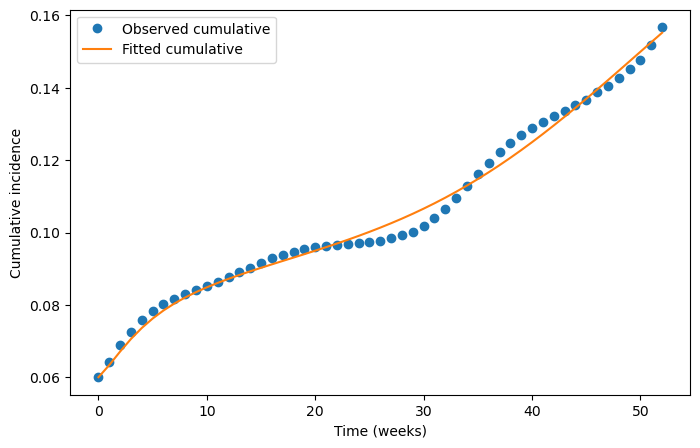

In [254]:
#Fitted cumulative curve and observed cumulative curve
fitted_states = simulate(result.x, t_eval, y0)

fitted_cumulative = fitted_states[6]

plt.figure(figsize=(8, 5))
plt.plot(t_eval, observed_cumulative, 'o', label='Observed cumulative')
plt.plot(t_eval, fitted_cumulative, '-', label='Fitted cumulative')
plt.xlabel('Time (weeks)')
plt.ylabel('Cumulative incidence')

plt.legend()
plt.grid(False)
plt.show()

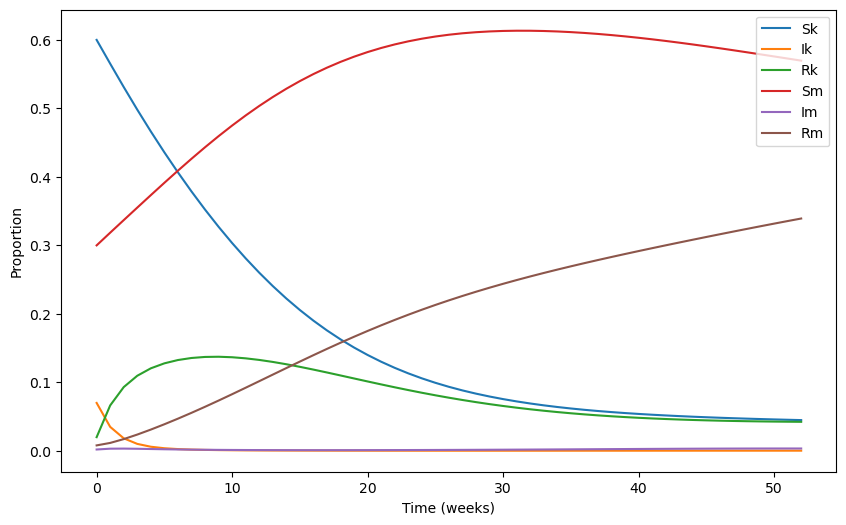

In [255]:
#Six compartments
Sk, Ik, Rk, Sm, Im, Rm, C = fitted_states

plt.figure(figsize=(10, 6))
plt.plot(t_eval, Sk, label='Sk')
plt.plot(t_eval, Ik, label='Ik')
plt.plot(t_eval, Rk, label='Rk')
plt.plot(t_eval, Sm, label='Sm')
plt.plot(t_eval, Im, label='Im')
plt.plot(t_eval, Rm, label='Rm')
plt.xlabel('Time (weeks)')
plt.ylabel('Proportion')
plt.legend()
plt.grid(False)
plt.show()

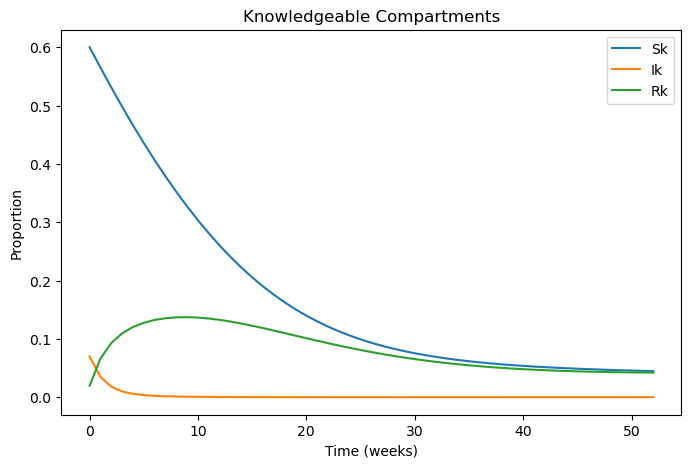

In [256]:
#Knowledgeable
plt.figure(figsize=(8, 5))
plt.plot(t_eval, Sk, label='Sk')
plt.plot(t_eval, Ik, label='Ik')
plt.plot(t_eval, Rk, label='Rk')
plt.xlabel('Time (weeks)')
plt.ylabel('Proportion')
plt.title('Knowledgeable Compartments')
plt.legend()
plt.grid(False)
plt.show()

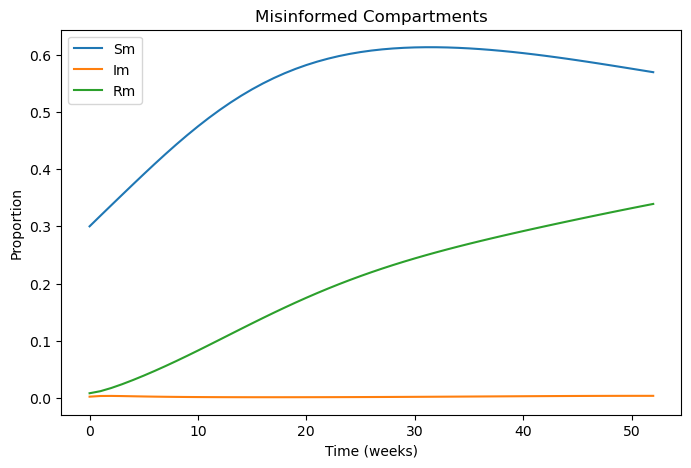

In [257]:
#Misinformed
plt.figure(figsize=(8, 5))
plt.plot(t_eval, Sm, label='Sm')
plt.plot(t_eval, Im, label='Im')
plt.plot(t_eval, Rm, label='Rm')
plt.xlabel('Time (weeks)')
plt.ylabel('Proportion')
plt.title('Misinformed Compartments')
plt.legend()
plt.grid(False)
plt.show()

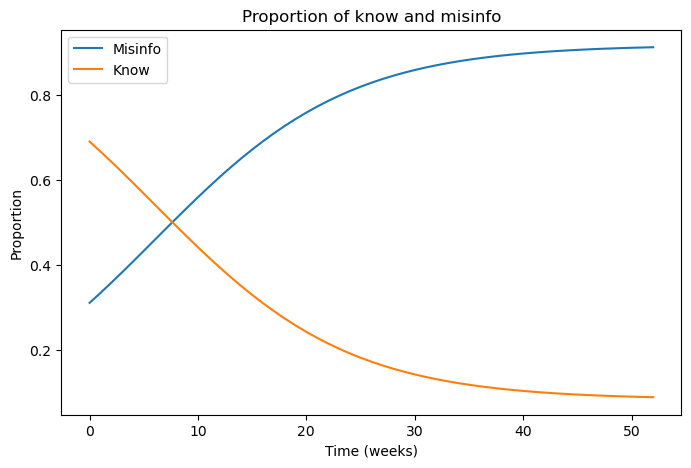

In [258]:
#Knowledgeabel proportion vs. Misinformed proportion
plt.figure(figsize=(8, 5))
plt.plot(t_eval, Sm + Im + Rm, label='Misinfo')
plt.plot(t_eval, Sk + Ik + Rk, label='Know')
plt.xlabel('Time (weeks)')
plt.ylabel('Proportion')
plt.title('Proportion of know and misinfo')
plt.legend()
plt.grid(False)
plt.show()